## Get and Format Data
### Only do this once (until someone changes the code)
1. Run all blocks in notebooks/bipartite_graph.ipynb
2. cd into notebooks
2. Run process_graphs.py
3. Run run_simulations.py (there are hyperparameters on the number of trajectories to simulate and expansion types)
4. Run this notebook

In [19]:
# General imports
import sys
import os

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv 
from torch_geometric.nn import GATv2Conv

# ----File Stitching----
# If in models folder, cd back to notebooks folder
if os.path.basename(os.getcwd()) == "models":
    os.chdir('..')
# If a file is in /src/, access it by telling the system to look at that path as well as current path
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

# Import from .py files 
from training import load_and_prepare_training_data, ImitationTrainer # Training script handles dataloaders 
train_dataloader, val_dataloader, static_graph = load_and_prepare_training_data()
node_dim = static_graph['x_static'].shape[1] + 1 
_, _, _, sample_event_feat = next(iter(train_dataloader))
event_dim = sample_event_feat.shape[1]

Loading imitation data from disk...
Loading index mappings...
Splitting data with 20.0% validation ratio...
Building PyTorch Train DataLoader...
Loading static graph topology...
Aligning static user features...
Aligning event features...
Building PyTorch Validation DataLoader...
Loading static graph topology...
Aligning static user features...
Aligning event features...


## Define Model

In [ ]:
class MultiplexSeedingModel(nn.Module):
    def __init__(self, node_dim, event_dim, edge_dim=1, hidden_dim=128):
        super().__init__()
        
        # Encoders
        self.node_encoder = nn.Linear(node_dim, hidden_dim)
        self.event_encoder = nn.Linear(event_dim, hidden_dim)
        
        # Parallel Message Passing
        self.conv1_1 = GATConv(hidden_dim, hidden_dim // 2, edge_dim=edge_dim)
        self.conv2_1 = GATConv(hidden_dim, hidden_dim // 2, edge_dim=edge_dim)
        
        self.fusion_layer = nn.Linear(hidden_dim, hidden_dim)
        
        # Final Scorer - input dim is hidden_dim * 2 due to node + event concatenation
        self.scorer = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x_batch, static_graph, event_feat_batch):
        """
        Args:
            x_batch: Tensor of shape [B, N, F+1] - matrix of all node embeddings, dependent on graph config 
                comprises imitation data results for multiple seed notification scenarios
            static_graph: Dict of pre-loaded, unbatched PyG topology tensors - connections between nodes 
                static_graph['edge_index_1'], static_graph['edge_attr_1'] = simple graphs
                static_graph['edge_index_2'], static_graph['edge_attr_2'] = 2simplex graph
            event_feat_batch: Tensor of shape [B, event_dim] - matrix of all event embeddings 
                corresponding to the seed notification scenarios
        """
        B, N, _ = x_batch.shape
        
        # 1. Initial Encodings
        x_encoded = F.relu(self.node_encoder(x_batch)) # [B, N, hidden_dim]
        event_encoded = F.relu(self.event_encoder(event_feat_batch)) # [B, hidden_dim]
        
        x_nodes_list = []
        
        # 2. Sequential Message Passing (Avoid OOM on large graphs)
        for b in range(B):
            x_b = x_encoded[b] # [N, hidden_dim]
            
            x_1 = F.elu(self.conv1_1(x_b, static_graph['edge_index_1'], static_graph['edge_attr_1']))
            x_2 = F.elu(self.conv2_1(x_b, static_graph['edge_index_2'], static_graph['edge_attr_2']))
            
            x_fused = torch.cat([x_1, x_2], dim=-1)
            x_nodes = F.relu(self.fusion_layer(x_fused)) # [N, hidden_dim]
            x_nodes_list.append(x_nodes)
            
        batch_x_nodes = torch.stack(x_nodes_list) # [B, N, hidden_dim]
        
        # 3. Contextualize with Event Features
        # Expand event embeddings to match node dimension: [B, hidden_dim] -> [B, N, hidden_dim]
        event_expanded = event_encoded.unsqueeze(1).expand(-1, N, -1)
        
        # Combine node representations with the target event context
        combined = torch.cat([batch_x_nodes, event_expanded], dim=-1) # [B, N, hidden_dim * 2]
        
        # 4. Score Nodes
        logits = self.scorer(combined).squeeze(-1) # [B, N]
        
        # 5. Autoregressive Masking
        # Mask out nodes that are already seeded (tracked in channel 0 of x_batch)
        seed_mask = x_batch[:, :, 0].bool()
        logits = logits.masked_fill(seed_mask, float('-1e9'))
        
        # Return raw logits to align with BCEWithLogitsLoss
        return logits

In [55]:
# Adapted code from 
    # https://towardsdatascience.com/graph-attention-networks-in-python-975736ac5c0c/
    # https://www.github.com/diegoantognini/pyGAT/blob/master/

# Define a Graph Attention Model class
class GAT_Model(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout, heads=1,edge_dim=1):
        super().__init__()
        self.dropout = dropout
        self.gat1 = GATv2Conv(in_dim, out_dim, heads=heads, edge_dim=edge_dim)
        
        #self.gat2 = GATv2Conv(hidden_dim * heads, out_dim, heads=1,edge_dim=edge_dim)
        self.optmizer = torch.optim.Adam(self.parameters(), lr=0.001)

    def forward(self,x_batch, static_graph,event_feat_batch): 
        # Obtain x_batch dimensions
        B, N, _ = x_batch.shape
        x_nodes_list =[]
        # For each node in x_batch, run it through a Gatv2Conv layer
        for b in range(B):
            x_b = x_batch[b]
            h = self.gat1(x_b,static_graph['edge_index_1'],static_graph['edge_attr_1'])
            x_nodes_list.append(h)
        # Combine all the nodes into a single tensor
        batch_x_nodes = torch.stack(x_nodes_list)
        batch_x_nodes = batch_x_nodes.squeeze(2)
        return batch_x_nodes
        
        
        
        
        # x_batch, static_graph, event_feat_batch
        # x_batch = x_batch.squeeze(0)
        #print(f"{x_batch.shape=}")
        # h = F.dropout(x_batch, p=0.5, training=self.training)
        #h = self.gat1(x_batch,static_graph['edge_index_1'],static_graph['edge_attr_1'])
        # h = F.elu(h)
        # h = F.dropout(h, p=0.5, training=self.training)
        # h = self.gat2(h,static_graph['edge_index_1'],static_graph['edge_attr_1'])
        # return h
    
    

## Run Training Script


Initializing model with Node Dim: 9, Event Dim: 64

Starting Training...
Starting training on cpu...
Epoch 1/10 | Train BCE: 5.5220 | Val BCE: 15.5899
Epoch 2/10 | Train BCE: 5.4810 | Val BCE: 15.4802
Epoch 3/10 | Train BCE: 5.4400 | Val BCE: 15.3706
Epoch 4/10 | Train BCE: 5.3989 | Val BCE: 15.2610
Epoch 5/10 | Train BCE: 5.3580 | Val BCE: 15.1514
Epoch 6/10 | Train BCE: 5.3170 | Val BCE: 15.0419
Epoch 7/10 | Train BCE: 5.2760 | Val BCE: 14.9324
Epoch 8/10 | Train BCE: 5.2351 | Val BCE: 14.8229
Epoch 9/10 | Train BCE: 5.1941 | Val BCE: 14.7134
Epoch 10/10 | Train BCE: 5.1532 | Val BCE: 14.6039
Training complete.
Loss curve saved to loss_curve.png
Loss curve saved to loss_curve.png


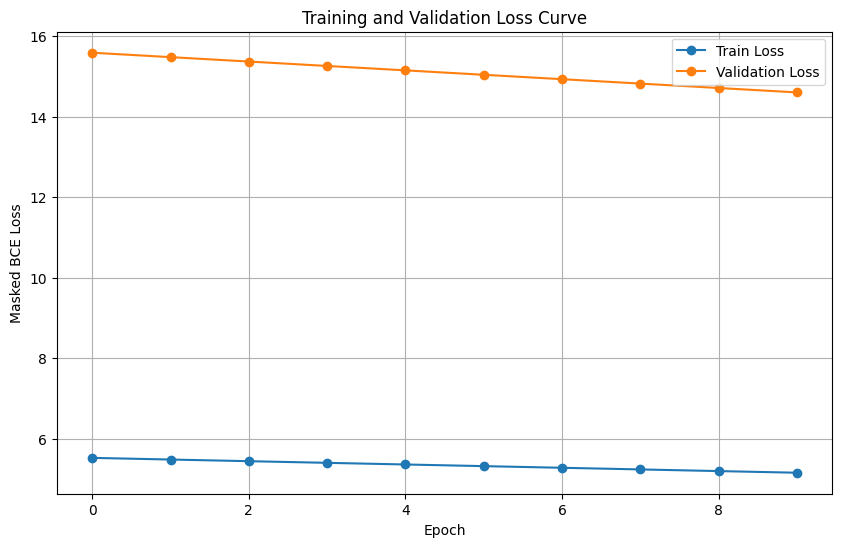

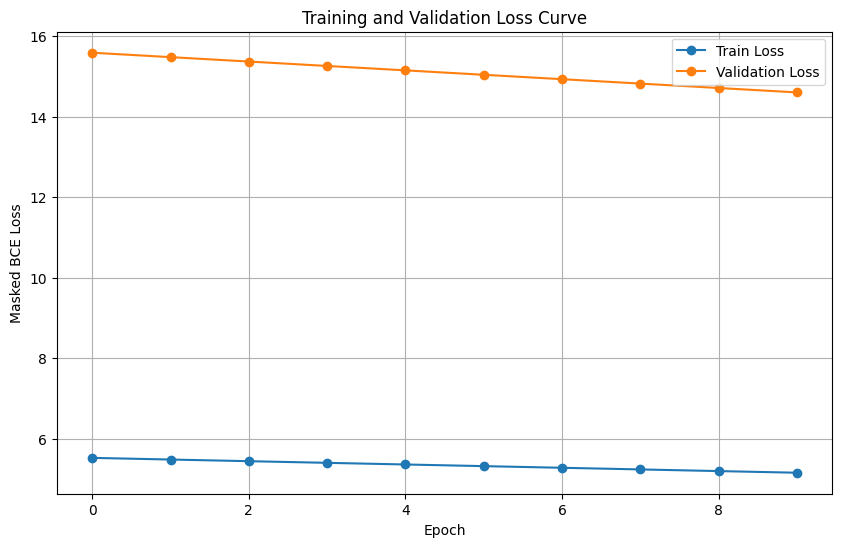

In [56]:
    
print(f"\nInitializing model with Node Dim: {node_dim}, Event Dim: {event_dim}")

model = GAT_Model(
    in_dim = -1,
    hidden_dim = 8,
    dropout=0.5,
    out_dim = 1
)

config = {
    'lr': 1e-3,
    'epochs': 10,
    'project_name': 'meetup-contagion-seeding',
    'run_name': 'mcmc-vectorized-run'
}

trainer = ImitationTrainer(
    model=model,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    static_graph=static_graph,
    config=config,
    use_wandb=False # Switch to False if wandb is not set up
)
print("\nStarting Training...")
trainer.train()
trainer.plot_losses()

Thoughts:
- Does model work without taking graphs into account?
- With only simple graphs?
- With simple AND hyper graphs?

In [ ]:
Thoughts: